<a id='II-6'></a>
## **6. Stationarity Testing**

In [9]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Load data ─────────────────────────────────────────────────────────────────
import pickle
with open('outputs/processed/cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)

monthly_sales = data['monthly_sales']

print("Ready!")
print(f"   monthly_sales: {len(monthly_sales)} rows")

Ready!
   monthly_sales: 48 rows


In [10]:
def test_stationarity(timeseries, title='Time Series'):
    """
    Comprehensive stationarity test:
    - Rolling statistics plot
    - ADF test
    - KPSS test
    """
    # ── Rolling Statistics ────────────────────────────────────────────────
    rolmean = timeseries.rolling(window=12).mean()
    rolstd  = timeseries.rolling(window=12).std()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(timeseries, color='steelblue',  label='Original', linewidth=1.5)
    ax.plot(rolmean,    color='firebrick',  label='Rolling Mean (12-mo)', linewidth=2)
    ax.plot(rolstd,     color='darkgreen',  label='Rolling Std (12-mo)',  linewidth=2)
    ax.set_title(f'Rolling Statistics — {title}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_xlabel('Date')
    plt.tight_layout()
    plt.show()

    # ── ADF Test ──────────────────────────────────────────────────────────
    print('=' * 55)
    print(f'  Augmented Dickey-Fuller (ADF) Test — {title}')
    print('=' * 55)
    adf_result = adfuller(timeseries.dropna(), autolag='AIC')
    adf_output = pd.Series(adf_result[0:4],
                           index=['Test Statistic', 'p-value',
                                  'Lags Used', 'Observations Used'])
    for key, value in adf_result[4].items():
        adf_output[f'Critical Value ({key})'] = value
    print(adf_output.round(4))

    if adf_result[1] <= 0.05:
        print(f"\n✅ ADF: p-value={adf_result[1]:.4f} ≤ 0.05 → STATIONARY (reject H₀)")
    else:
        print(f"\n❌ ADF: p-value={adf_result[1]:.4f} > 0.05 → NON-STATIONARY (fail to reject H₀)")

    # ── KPSS Test ─────────────────────────────────────────────────────────
    print()
    print('=' * 55)
    print(f'  KPSS Test — {title}')
    print('=' * 55)
    kpss_result = kpss(timeseries.dropna(), regression='c', nlags='auto')
    kpss_output = pd.Series(kpss_result[0:3],
                            index=['Test Statistic', 'p-value', 'Lags Used'])
    for key, value in kpss_result[3].items():
        kpss_output[f'Critical Value ({key})'] = value
    print(kpss_output.round(4))

    if kpss_result[1] <= 0.05:
        print(f"\n❌ KPSS: p-value={kpss_result[1]:.4f} ≤ 0.05 → NON-STATIONARY (reject H₀)")
    else:
        print(f"\n KPSS: p-value={kpss_result[1]:.4f} > 0.05 → STATIONARY (fail to reject H₀)")
    print()

print(" test_stationarity() function defined.")

 test_stationarity() function defined.


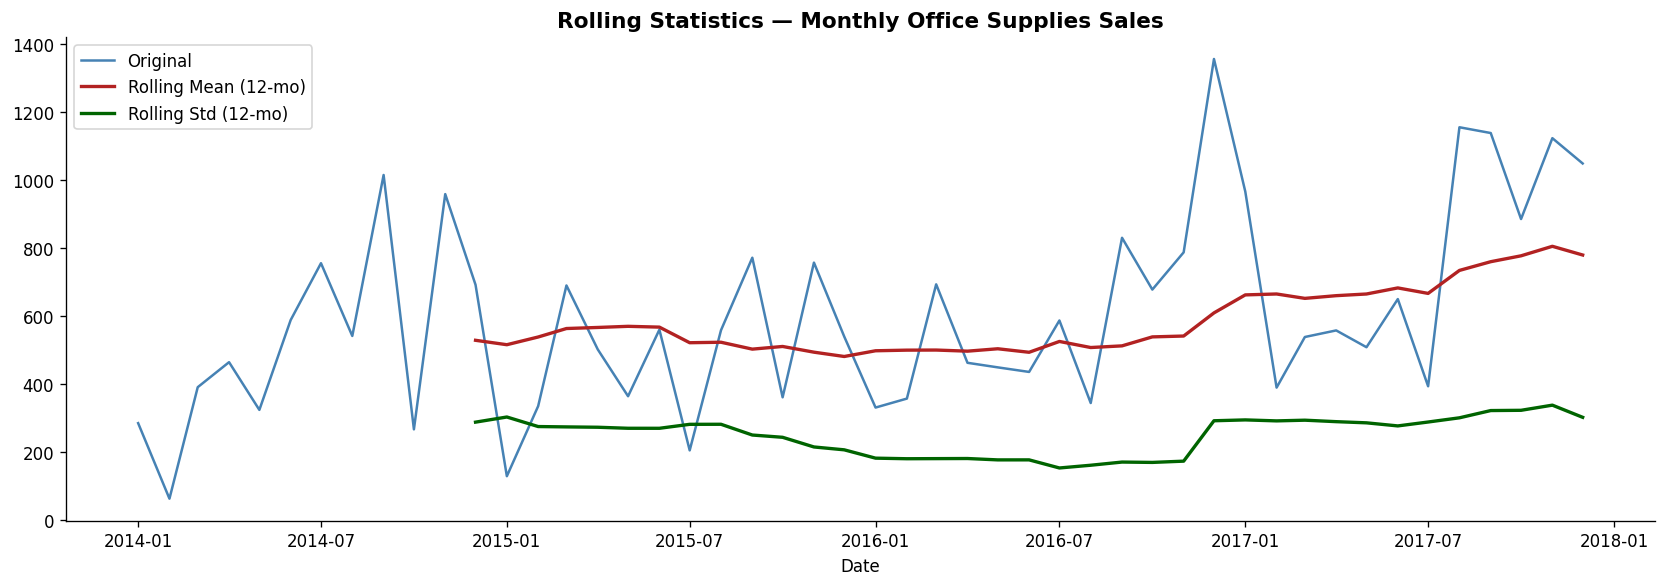

  Augmented Dickey-Fuller (ADF) Test — Monthly Office Supplies Sales
Test Statistic          -4.6646
p-value                  0.0001
Lags Used                0.0000
Observations Used       47.0000
Critical Value (1%)     -3.5778
Critical Value (5%)     -2.9253
Critical Value (10%)    -2.6008
dtype: float64

✅ ADF: p-value=0.0001 ≤ 0.05 → STATIONARY (reject H₀)

  KPSS Test — Monthly Office Supplies Sales
Test Statistic           0.5949
p-value                  0.0231
Lags Used                3.0000
Critical Value (10%)     0.3470
Critical Value (5%)      0.4630
Critical Value (2.5%)    0.5740
Critical Value (1%)      0.7390
dtype: float64

❌ KPSS: p-value=0.0231 ≤ 0.05 → NON-STATIONARY (reject H₀)



In [11]:
# Test stationarity on the original monthly series
test_stationarity(monthly_sales, title='Monthly Office Supplies Sales')

<a id='II-7'></a>
## **7. Making the Series Stationary**

We compare four approaches and identify the most effective one.

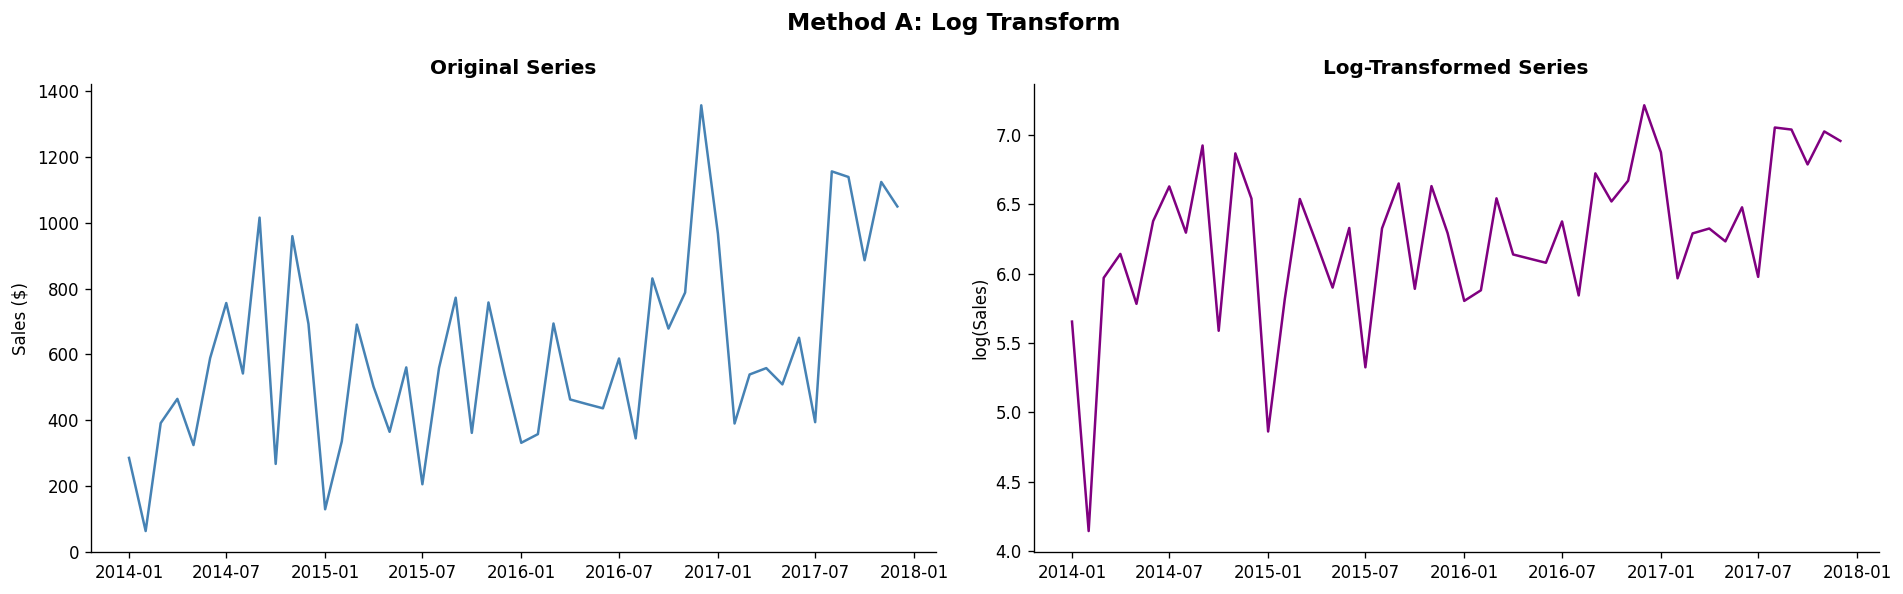

💡 Log transform stabilizes variance but may not fully remove trend.


In [12]:
# ── Method A: Log Transform ──────────────────────────────────────────────────
ts_log = np.log(monthly_sales)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(monthly_sales, color='steelblue')
axes[0].set_title('Original Series', fontweight='bold')
axes[0].set_ylabel('Sales ($)')

axes[1].plot(ts_log, color='purple')
axes[1].set_title('Log-Transformed Series', fontweight='bold')
axes[1].set_ylabel('log(Sales)')

plt.suptitle('Method A: Log Transform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Log transform stabilizes variance but may not fully remove trend.")

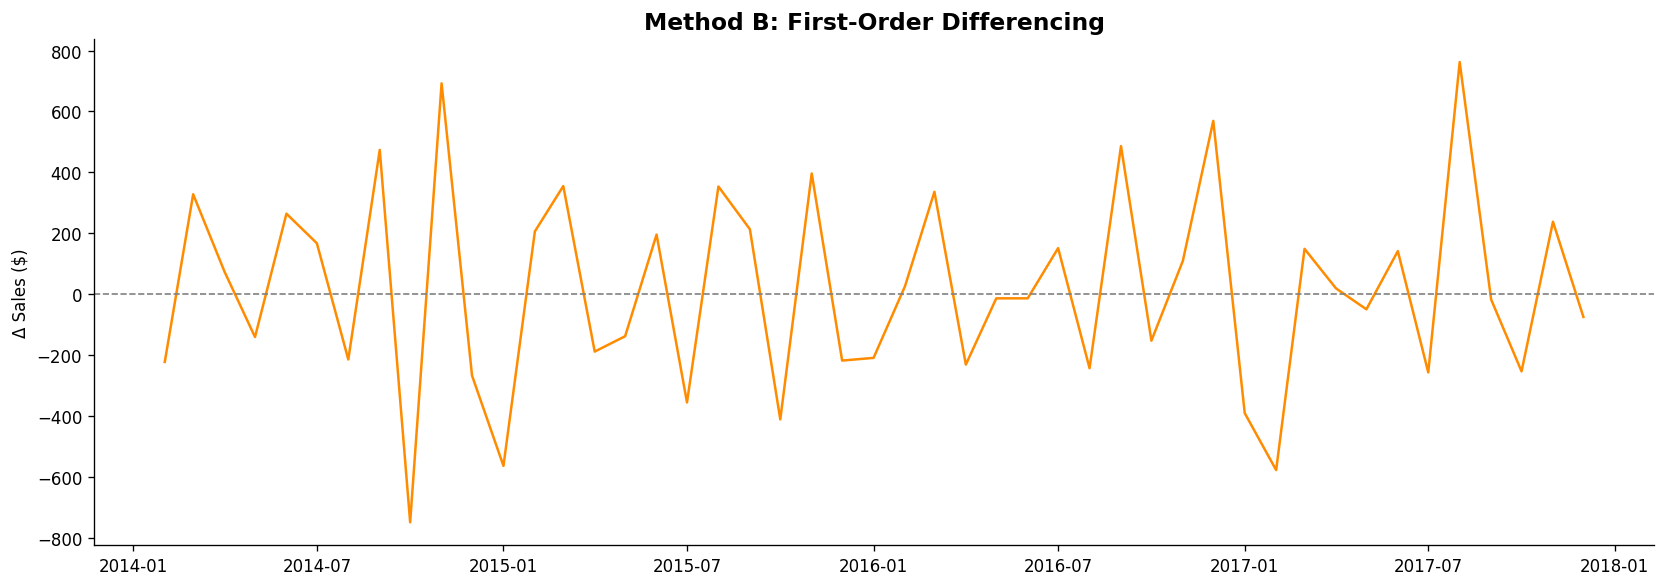

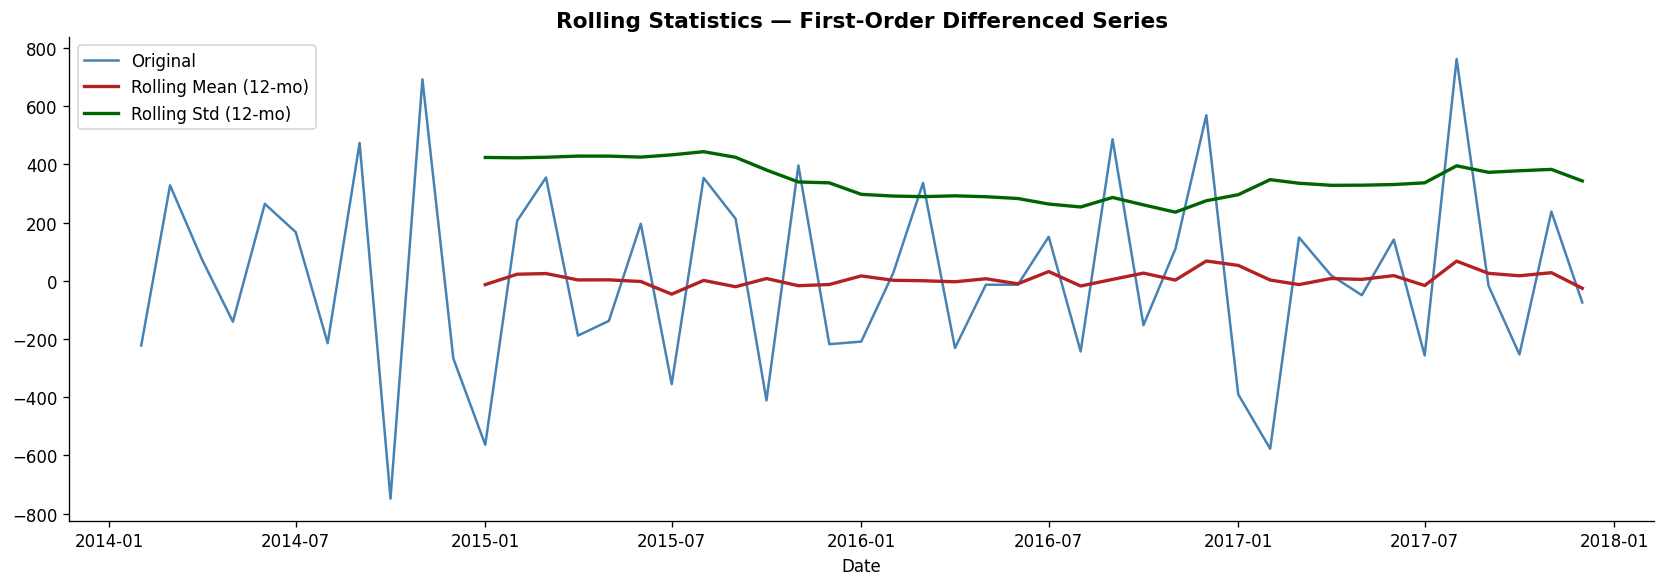

  Augmented Dickey-Fuller (ADF) Test — First-Order Differenced Series
Test Statistic          -8.6031
p-value                  0.0000
Lags Used                1.0000
Observations Used       45.0000
Critical Value (1%)     -3.5848
Critical Value (5%)     -2.9283
Critical Value (10%)    -2.6023
dtype: float64

✅ ADF: p-value=0.0000 ≤ 0.05 → STATIONARY (reject H₀)

  KPSS Test — First-Order Differenced Series
Test Statistic            0.1863
p-value                   0.1000
Lags Used                17.0000
Critical Value (10%)      0.3470
Critical Value (5%)       0.4630
Critical Value (2.5%)     0.5740
Critical Value (1%)       0.7390
dtype: float64

 KPSS: p-value=0.1000 > 0.05 → STATIONARY (fail to reject H₀)



C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\1582359507.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries.dropna(), regression='c', nlags='auto')


In [13]:
# ── Method B: First-Order Differencing ──────────────────────────────────────
ts_diff1 = monthly_sales.diff().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_diff1, color='darkorange', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Method B: First-Order Differencing', fontsize=14, fontweight='bold')
ax.set_ylabel('Δ Sales ($)')
plt.tight_layout()
plt.show()

test_stationarity(ts_diff1, title='First-Order Differenced Series')

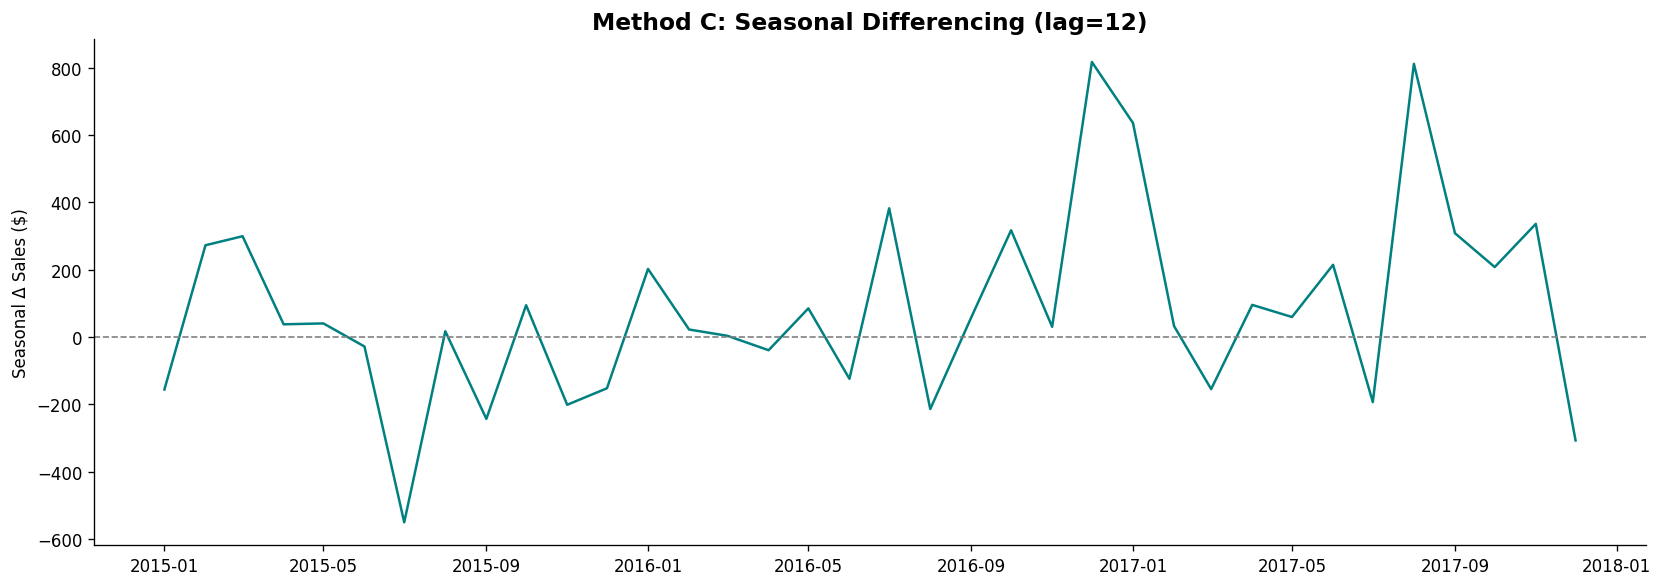

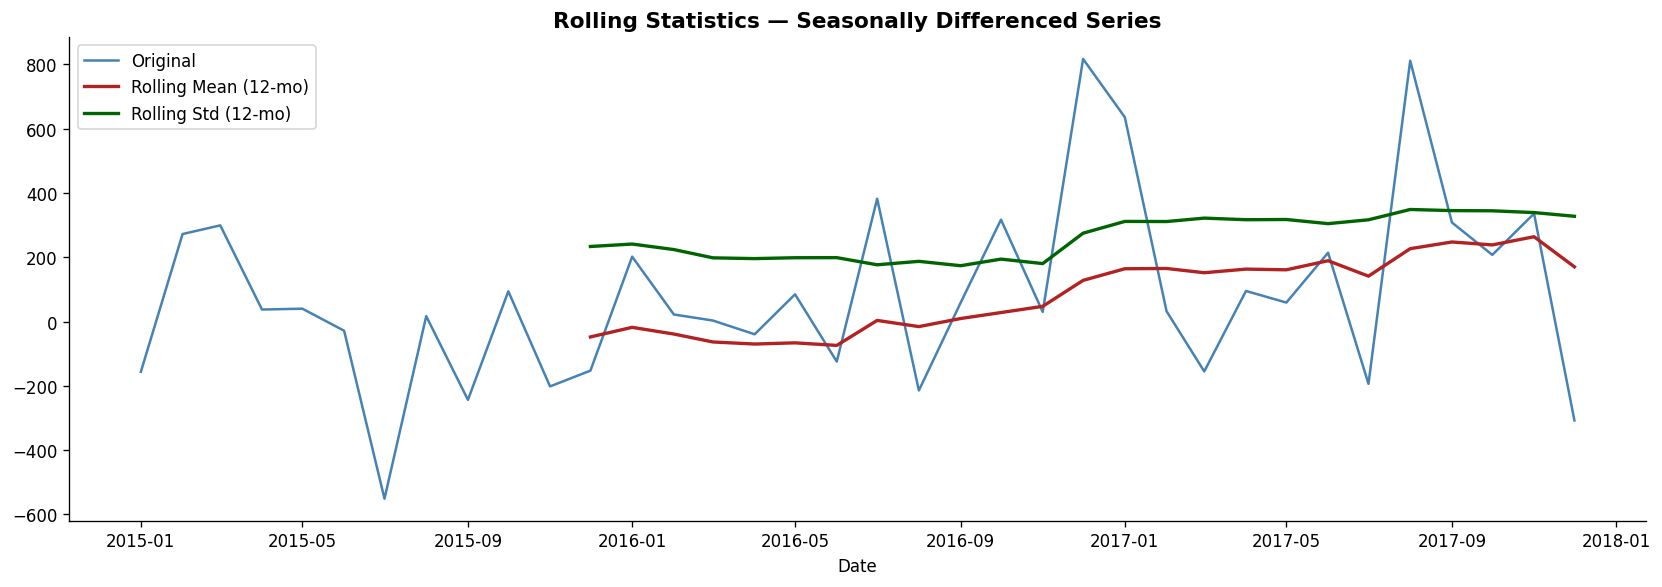

  Augmented Dickey-Fuller (ADF) Test — Seasonally Differenced Series
Test Statistic          -5.1912
p-value                  0.0000
Lags Used                0.0000
Observations Used       35.0000
Critical Value (1%)     -3.6327
Critical Value (5%)     -2.9485
Critical Value (10%)    -2.6130
dtype: float64

✅ ADF: p-value=0.0000 ≤ 0.05 → STATIONARY (reject H₀)

  KPSS Test — Seasonally Differenced Series
Test Statistic           0.3615
p-value                  0.0937
Lags Used                2.0000
Critical Value (10%)     0.3470
Critical Value (5%)      0.4630
Critical Value (2.5%)    0.5740
Critical Value (1%)      0.7390
dtype: float64

 KPSS: p-value=0.0937 > 0.05 → STATIONARY (fail to reject H₀)



In [14]:
# ── Method C: Seasonal Differencing (lag=12) ─────────────────────────────────
ts_seasonal_diff = monthly_sales.diff(12).dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_seasonal_diff, color='teal', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Method C: Seasonal Differencing (lag=12)', fontsize=14, fontweight='bold')
ax.set_ylabel('Seasonal Δ Sales ($)')
plt.tight_layout()
plt.show()

test_stationarity(ts_seasonal_diff, title='Seasonally Differenced Series')

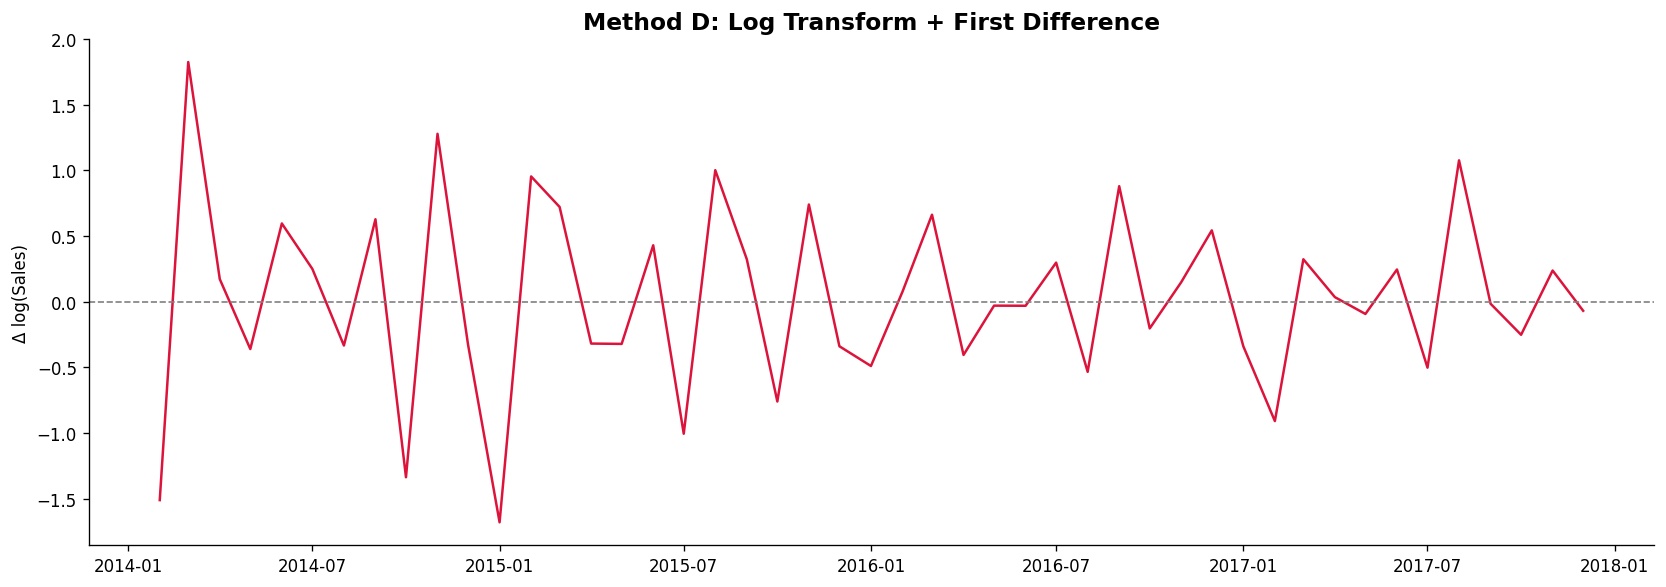

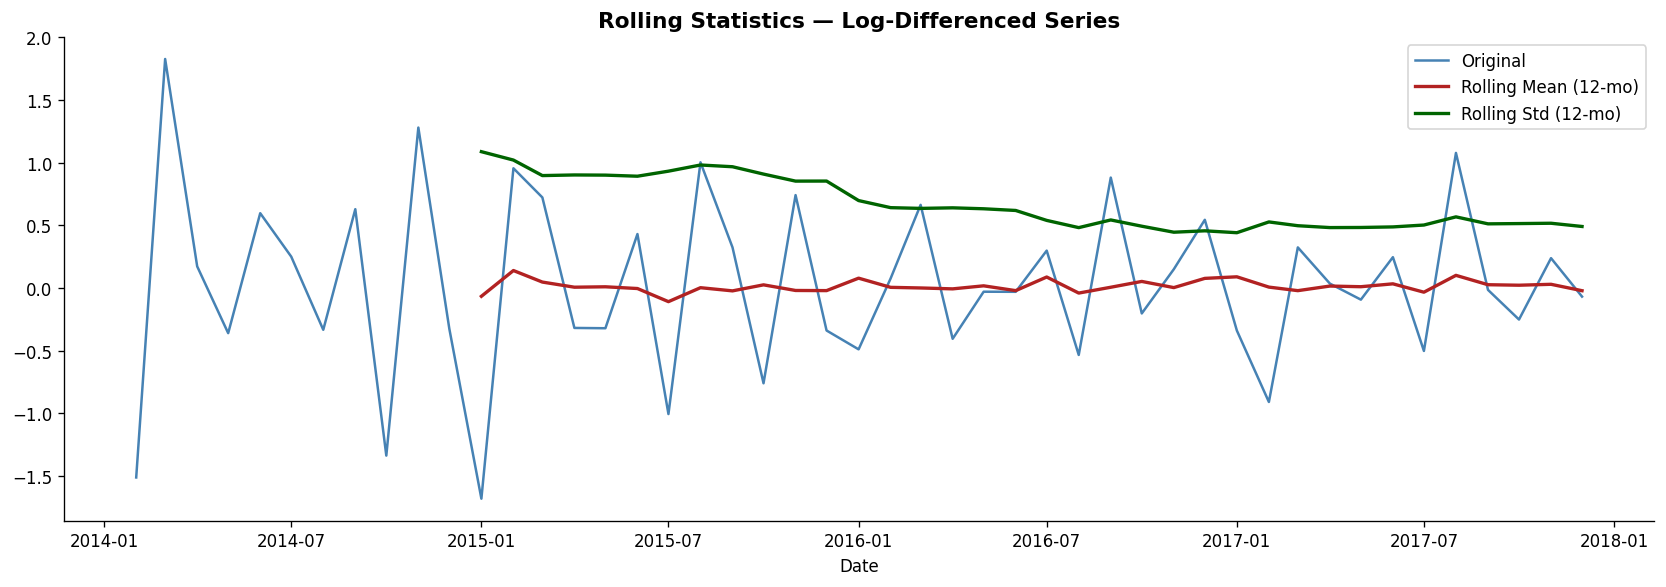

  Augmented Dickey-Fuller (ADF) Test — Log-Differenced Series
Test Statistic          -4.7719
p-value                  0.0001
Lags Used                9.0000
Observations Used       37.0000
Critical Value (1%)     -3.6209
Critical Value (5%)     -2.9435
Critical Value (10%)    -2.6104
dtype: float64

✅ ADF: p-value=0.0001 ≤ 0.05 → STATIONARY (reject H₀)

  KPSS Test — Log-Differenced Series
Test Statistic            0.145
p-value                   0.100
Lags Used                13.000
Critical Value (10%)      0.347
Critical Value (5%)       0.463
Critical Value (2.5%)     0.574
Critical Value (1%)       0.739
dtype: float64

 KPSS: p-value=0.1000 > 0.05 → STATIONARY (fail to reject H₀)



C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\1582359507.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries.dropna(), regression='c', nlags='auto')


In [15]:
# ── Method D: Log + First Difference (combined) ───────────────────────────
ts_log_diff = ts_log.diff().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_log_diff, color='crimson', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Method D: Log Transform + First Difference', fontsize=14, fontweight='bold')
ax.set_ylabel('Δ log(Sales)')
plt.tight_layout()
plt.show()

test_stationarity(ts_log_diff, title='Log-Differenced Series')

In [16]:
# ── Summary of stationarity results ─────────────────────────────────────────
print("="*60)
print("       STATIONARITY TEST SUMMARY")
print("="*60)
methods = {
    'Original':                  monthly_sales,
    'Log Transform':             ts_log,
    'First Difference':          ts_diff1,
    'Seasonal Diff (lag=12)':    ts_seasonal_diff,
    'Log + First Diff':          ts_log_diff,
}

results = []
for name, series in methods.items():
    try:
        adf = adfuller(series.dropna(), autolag='AIC')
        stationary = '✅ Stationary' if adf[1] <= 0.05 else '❌ Non-Stationary'
        results.append({'Method': name, 'ADF Stat': round(adf[0], 4),
                        'p-value': round(adf[1], 4), 'Result': stationary})
    except Exception as e:
        results.append({'Method': name, 'ADF Stat': 'Error', 'p-value': 'Error', 'Result': str(e)})

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))
print("\n💡 Conclusion: First-order differencing (d=1) achieves stationarity.")
print("   SARIMAX will handle seasonal component with D=1, m=12.")

       STATIONARITY TEST SUMMARY
                Method  ADF Stat  p-value           Result
              Original   -4.6646   0.0001     ✅ Stationary
         Log Transform   -2.8598   0.0502 ❌ Non-Stationary
      First Difference   -8.6031   0.0000     ✅ Stationary
Seasonal Diff (lag=12)   -5.1912   0.0000     ✅ Stationary
      Log + First Diff   -4.7719   0.0001     ✅ Stationary

💡 Conclusion: First-order differencing (d=1) achieves stationarity.
   SARIMAX will handle seasonal component with D=1, m=12.
